##  Step 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.21.0
GPU        : False


##  Step 2 — Load CIFAR-10

In [2]:
(X_train_raw, y_train), (X_test_raw, y_test) = cifar10.load_data()

CLASS_NAMES = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

print(f'Train : {X_train_raw.shape}  |  Test : {X_test_raw.shape}')
print(f'Pixel range : [{X_train_raw.min()}, {X_train_raw.max()}]')

Train : (50000, 32, 32, 3)  |  Test : (10000, 32, 32, 3)
Pixel range : [0, 255]


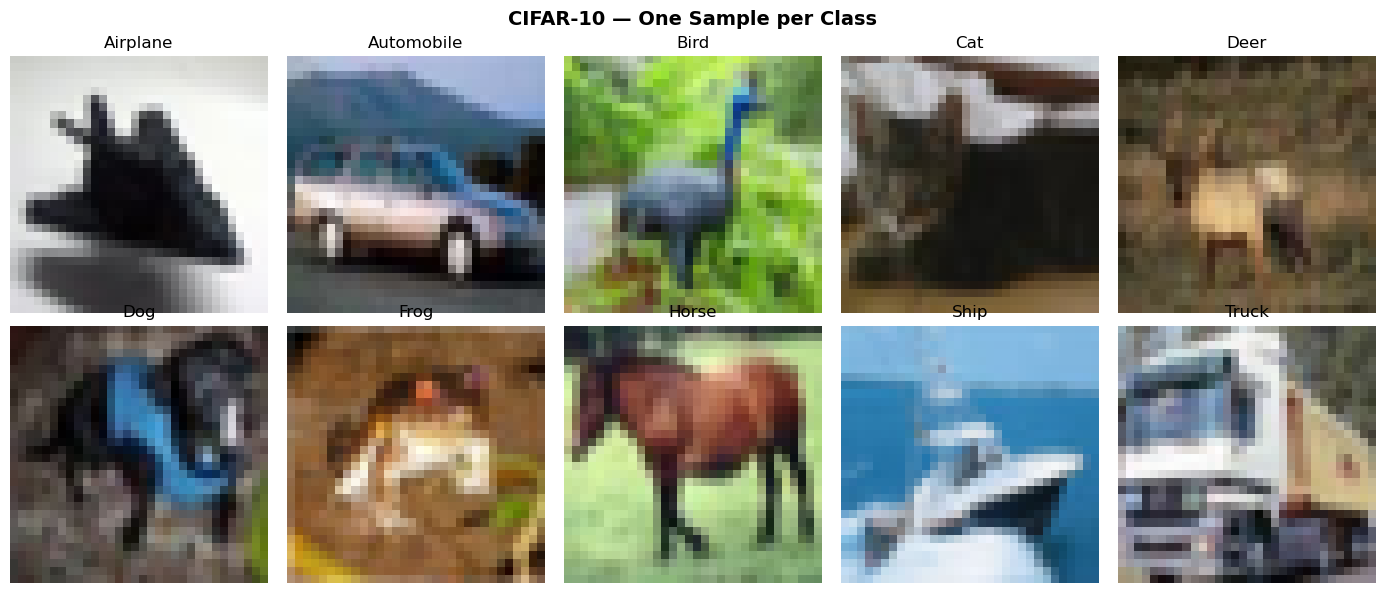

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CIFAR-10 — One Sample per Class', fontsize=14, fontweight='bold')
for cls_idx, ax in enumerate(axes.flat):
    idx = np.where(y_train.flatten() == cls_idx)[0][0]
    ax.imshow(X_train_raw[idx])
    ax.set_title(CLASS_NAMES[cls_idx]); ax.axis('off')
plt.tight_layout(); plt.show()

##  Step 3 — Normalise (0–255 → 0.0–1.0)

In [4]:
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

# Flat vectors for ANN
X_train_flat = X_train.reshape(X_train.shape[0], -1)   # (50000, 3072)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1)   # (10000, 3072)

print(f'Normalised range : [{X_train.min()}, {X_train.max()}]')
print(f'Flat shape       : {X_train_flat.shape}')

Normalised range : [0.0, 1.0]
Flat shape       : (50000, 3072)


##  Step 4 — Baseline ANN (Dense + Dropout)

In [5]:
def build_ann(input_dim=3072, num_classes=10):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ], name='ANN_Baseline')
    return model

ann_model = build_ann()
ann_model.summary()

Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

ann_history = ann_model.fit(
    X_train_flat, y_train,
    epochs=10, batch_size=128,
    validation_data=(X_test_flat, y_test),
    verbose=1
)

ann_loss, ann_acc = ann_model.evaluate(X_test_flat, y_test, verbose=0)
print(f'\nANN  →  Test Accuracy: {ann_acc*100:.2f}%  |  Loss: {ann_loss:.4f}')

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 61s 110ms/step - accuracy: 0.2386 - loss: 2.0547 - val_accuracy: 0.3400 - val_loss: 1.8465
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 77s 96ms/step - accuracy: 0.2986 - loss: 1.9102 - val_accuracy: 0.3697 - val_loss: 1.7888
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.3190 - loss: 1.8717 - val_accuracy: 0.3808 - val_loss: 1.7638
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.3309 - loss: 1.8352 - val_accuracy: 0.3912 - val_loss: 1.7472
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.3388 - loss: 1.8146 - val_accuracy: 0.3860 - val_loss: 1.7390
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 98ms/step - accuracy: 0.3508 - loss: 1.7855 - val_accuracy: 0.3884 - val_loss: 1.7246
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.3532 - loss: 1.7759 - val_accuracy: 0.4122 - val_loss: 1.6771
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.3666 - loss: 1.7534 -

##  Step 5 — CNN (Conv2D · BatchNorm · MaxPool)

In [7]:
def build_cnn(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1 — 32 filters
        layers.Conv2D(32,(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32,(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2 — 64 filters
        layers.Conv2D(64,(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64,(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3 — 128 filters
        layers.Conv2D(128,(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128,(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Dense head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_Baseline')
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [8]:
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_history = cnn_model.fit(
    X_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f'\nCNN  →  Test Accuracy: {cnn_acc*100:.2f}%  |  Loss: {cnn_loss:.4f}')

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 673s 782ms/step - accuracy: 0.4615 - loss: 1.5973 - val_accuracy: 0.5948 - val_loss: 1.1463
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 572s 731ms/step - accuracy: 0.6489 - loss: 0.9948 - val_accuracy: 0.6908 - val_loss: 0.8858
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 554s 708ms/step - accuracy: 0.7115 - loss: 0.8248 - val_accuracy: 0.7251 - val_loss: 0.8000
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 595s 760ms/step - accuracy: 0.7452 - loss: 0.7285 - val_accuracy: 0.7515 - val_loss: 0.7110
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 503s 643ms/step - accuracy: 0.7895 - loss: 0.6036 - val_accuracy: 0.7236 - val_loss: 0.8050
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 418s 534ms/step - accuracy: 0.8071 - loss: 0.5550 - val_accuracy: 0.7690 - val_loss: 0.6688
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 261s 298ms/step - accuracy: 0.8212 - loss: 0.5165 - val_accuracy: 0.8098 - val_loss: 0.5658
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 224s 286ms/step - accuracy: 0.8340 -

##  Step 6 — Validation Accuracy Curve: ANN vs CNN (10 Epochs)
> Dedicated side-by-side comparison of both baselines over exactly 10 epochs.

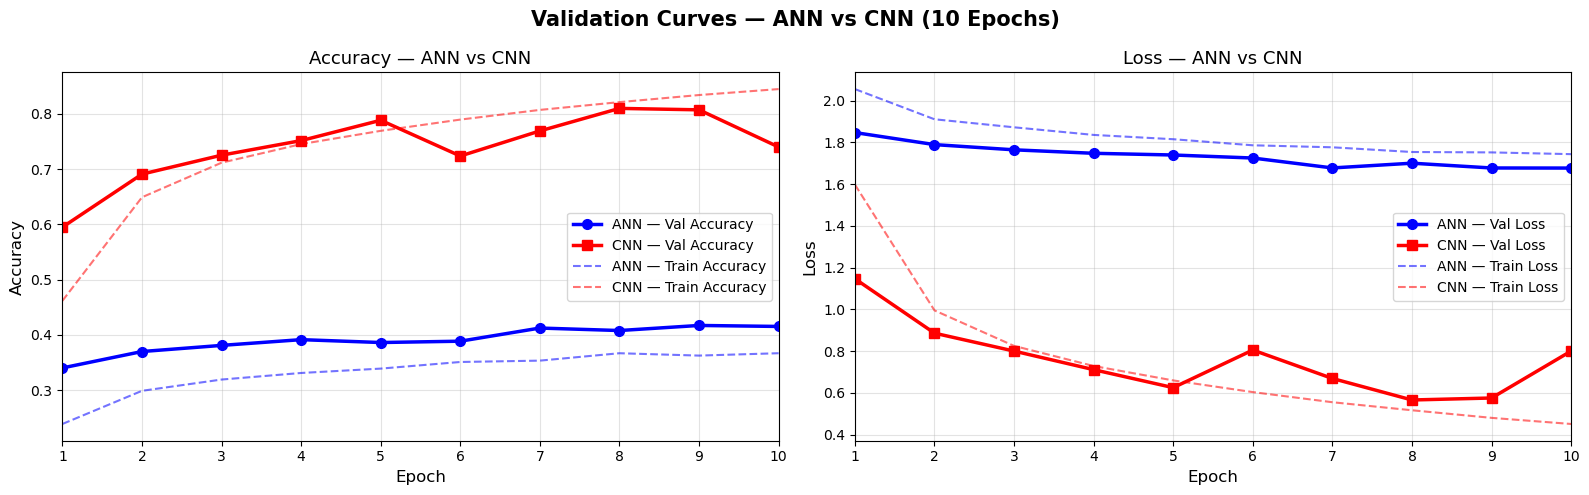

ANN  best val accuracy : 41.69%
CNN  best val accuracy : 80.98%


In [9]:
epochs_range = range(1, 11)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Validation Curves — ANN vs CNN (10 Epochs)', fontsize=15, fontweight='bold')

# --- Left: Validation Accuracy ---
ax = axes[0]
ax.plot(epochs_range, ann_history.history['val_accuracy'],
        'b-o', label='ANN — Val Accuracy', linewidth=2.5, markersize=7)
ax.plot(epochs_range, cnn_history.history['val_accuracy'],
        'r-s', label='CNN — Val Accuracy', linewidth=2.5, markersize=7)
ax.plot(epochs_range, ann_history.history['accuracy'],
        'b--', label='ANN — Train Accuracy', linewidth=1.5, alpha=0.55)
ax.plot(epochs_range, cnn_history.history['accuracy'],
        'r--', label='CNN — Train Accuracy', linewidth=1.5, alpha=0.55)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy — ANN vs CNN', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)
ax.set_xlim([1, 10])

# --- Right: Validation Loss ---
ax = axes[1]
ax.plot(epochs_range, ann_history.history['val_loss'],
        'b-o', label='ANN — Val Loss', linewidth=2.5, markersize=7)
ax.plot(epochs_range, cnn_history.history['val_loss'],
        'r-s', label='CNN — Val Loss', linewidth=2.5, markersize=7)
ax.plot(epochs_range, ann_history.history['loss'],
        'b--', label='ANN — Train Loss', linewidth=1.5, alpha=0.55)
ax.plot(epochs_range, cnn_history.history['loss'],
        'r--', label='CNN — Train Loss', linewidth=1.5, alpha=0.55)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Loss — ANN vs CNN', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)
ax.set_xlim([1, 10])

plt.tight_layout()
plt.show()

print(f'ANN  best val accuracy : {max(ann_history.history["val_accuracy"])*100:.2f}%')
print(f'CNN  best val accuracy : {max(cnn_history.history["val_accuracy"])*100:.2f}%')

##  Step 7 — Augmented CNN (RandomFlip · RandomRotation · RandomZoom)

In [10]:
def build_augmented_cnn(input_shape=(32,32,3), num_classes=10):
    data_augmentation = models.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name='Augmentation')

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters,(3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters,(3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='CNN_Augmented')

aug_cnn_model = build_augmented_cnn()
aug_cnn_model.summary()

Model: "CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,54

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

###  Task 1 — Increased Dense Layout (ANN: 512 → 256 → 128)
> Already implemented in Step 4. Shown here for explicit reference.

In [11]:
# Task 1: Dense layer configuration used in ANN
# Original simple baseline would use a single Dense(256) layer.
# We expanded to three blocks: Dense(512) -> Dense(256) -> Dense(128)
# This gives the ANN more representational capacity at each abstraction level.

print('ANN Dense Layer Configuration:')
for layer in ann_model.layers:
    if hasattr(layer, 'units'):
        print(f'  {layer.name:25s}  units={layer.units}')

ANN Dense Layer Configuration:
  dense                      units=512
  dense_1                    units=256
  dense_2                    units=128
  dense_3                    units=10


###  Task 2 — Filter Scaling: 32 → 64 → 128
> Already implemented in Step 5. Confirmed here explicitly.

In [12]:
# Task 2: Filter size scaling across CNN blocks
# Block 1: Conv2D(32) — detects low-level edges, corners
# Block 2: Conv2D(64) — combines edges into shapes/textures
# Block 3: Conv2D(128) — recognises complex object parts

print('CNN Convolutional Filter Configuration:')
for layer in cnn_model.layers:
    if isinstance(layer, layers.Conv2D):
        print(f'  {layer.name:30s}  filters={layer.filters}  kernel={layer.kernel_size}')

CNN Convolutional Filter Configuration:
  conv2d                          filters=32  kernel=(3, 3)
  conv2d_1                        filters=32  kernel=(3, 3)
  conv2d_2                        filters=64  kernel=(3, 3)
  conv2d_3                        filters=64  kernel=(3, 3)
  conv2d_4                        filters=128  kernel=(3, 3)
  conv2d_5                        filters=128  kernel=(3, 3)


###  Task 3 — Training Extended to 20 Epochs

In [13]:
# Task 3 + 4 + 5: Train augmented CNN for up to 20 epochs with EarlyStopping

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: EarlyStopping integration
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,  # roll back to best checkpoint automatically
    verbose=1
)

# Task 5: Execute augmented network training
print('Training Augmented CNN — up to 20 epochs with EarlyStopping …')
aug_history = aug_cnn_model.fit(
    X_train, y_train,
    epochs=20,          # Task 3: 20 epochs
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],  # Task 4: EarlyStopping
    verbose=1
)

actual_epochs_aug = len(aug_history.history['accuracy'])
print(f'\nStopped after {actual_epochs_aug} epochs (patience=4).')

Training Augmented CNN — up to 20 epochs with EarlyStopping …
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 231s 284ms/step - accuracy: 0.3959 - loss: 1.7874 - val_accuracy: 0.5340 - val_loss: 1.2972
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 210s 268ms/step - accuracy: 0.5343 - loss: 1.3012 - val_accuracy: 0.6097 - val_loss: 1.1278
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 229s 292ms/step - accuracy: 0.5912 - loss: 1.1486 - val_accuracy: 0.6201 - val_loss: 1.0883
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 256s 285ms/step - accuracy: 0.6342 - loss: 1.0415 - val_accuracy: 0.6614 - val_loss: 0.9945
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 274s 300ms/step - accuracy: 0.6612 - loss: 0.9735 - val_accuracy: 0.6839 - val_loss: 0.9199
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 225s 287ms/step - accuracy: 0.6828 - loss: 0.9106 - val_accuracy: 0.6355 - val_loss: 1.0548
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 261s 287ms/step - accuracy: 0.6987 - loss: 0.8680 - val_accuracy: 0.7343 - val_loss: 0.7806
Epoch 8/20
782

###  Task 4 — EarlyStopping Callback (implemented above)
> EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True) — already active in Task 3 cell.

### Task 5 — Augmented Network Training Run (executed above)
> Training complete. Evaluate below.

In [14]:
aug_loss, aug_acc = aug_cnn_model.evaluate(X_test, y_test, verbose=0)
print(f'Augmented CNN  →  Test Accuracy: {aug_acc*100:.2f}%  |  Loss: {aug_loss:.4f}')

Augmented CNN  →  Test Accuracy: 82.52%  |  Loss: 0.5271


---
##  Tasks — All 5 Implemented

| # | Task | Status |
|---|------|--------|
| 1 | Increase dense layout configurations in ANN |  Done in Step 4 (512→256→128) |
| 2 | Scale up filter sizes 32→64→128 in CNN |  Done in Step 5 |
| 3 | Increase training to 20 epochs (Augmented CNN) |  Done  |
| 4 | Integrate EarlyStopping callback |  Done  |
| 5 | Execute augmented network training run |  Done  |

---
##  Step 8 — Three-Way Validation Accuracy Chart (ANN · CNN · Aug-CNN)

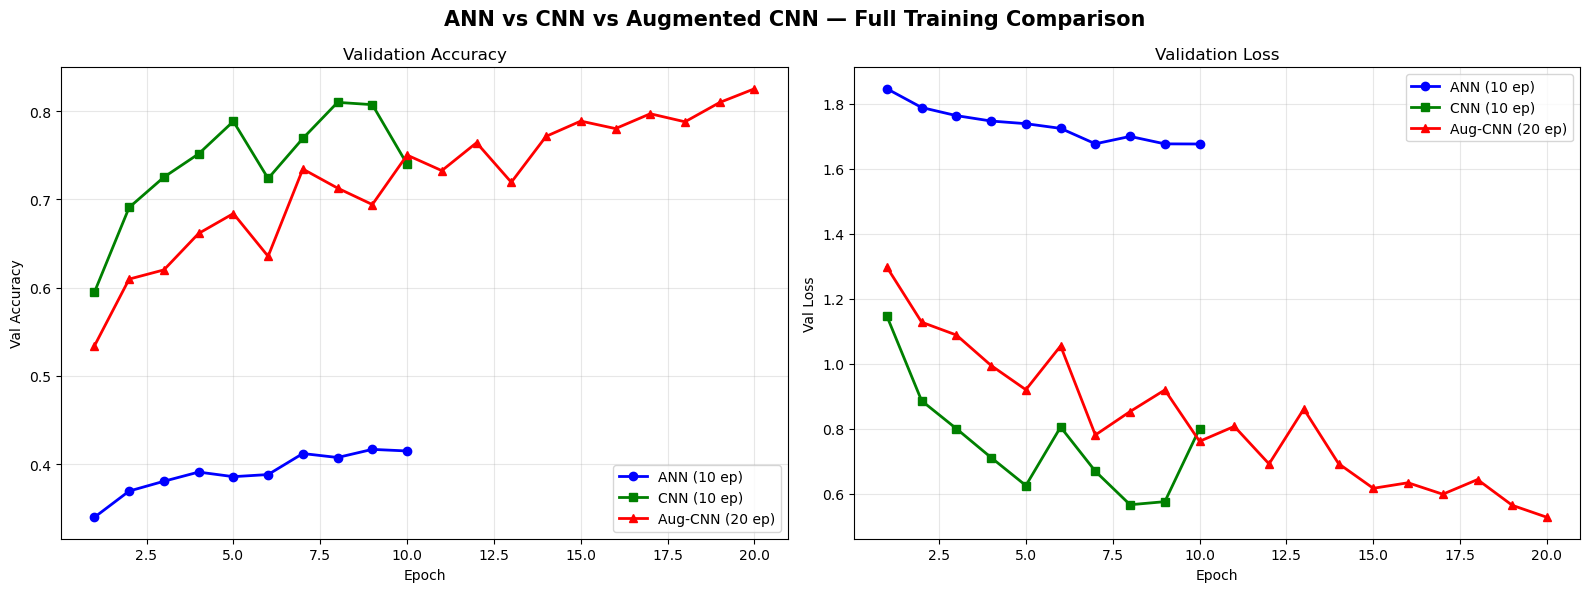

In [15]:
actual_epochs_aug = len(aug_history.history['val_accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ANN vs CNN vs Augmented CNN — Full Training Comparison',
             fontsize=15, fontweight='bold')

# Accuracy
ax = axes[0]
ax.plot(range(1,11), ann_history.history['val_accuracy'],
        'b-o', label='ANN (10 ep)', lw=2, ms=6)
ax.plot(range(1,11), cnn_history.history['val_accuracy'],
        'g-s', label='CNN (10 ep)', lw=2, ms=6)
ax.plot(range(1, actual_epochs_aug+1), aug_history.history['val_accuracy'],
        'r-^', label=f'Aug-CNN ({actual_epochs_aug} ep)', lw=2, ms=6)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
ax.set_title('Validation Accuracy'); ax.legend(); ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(range(1,11), ann_history.history['val_loss'],
        'b-o', label='ANN (10 ep)', lw=2, ms=6)
ax.plot(range(1,11), cnn_history.history['val_loss'],
        'g-s', label='CNN (10 ep)', lw=2, ms=6)
ax.plot(range(1, actual_epochs_aug+1), aug_history.history['val_loss'],
        'r-^', label=f'Aug-CNN ({actual_epochs_aug} ep)', lw=2, ms=6)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Loss')
ax.set_title('Validation Loss'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

##  Step 9 — Final Comparison DataFrame
> Structured pandas DataFrame contrasting all model variants across key metrics.

In [16]:
import pandas as pd

results_df = pd.DataFrame({
    'Model': [
        'ANN Baseline',
        'CNN Baseline',
        'CNN + Augmentation'
    ],
    'Architecture': [
        'Dense(512→256→128) + Dropout',
        'Conv2D(32→64→128) + BN + MaxPool',
        'Conv2D(32→64→128) + RandomFlip/Rotate/Zoom'
    ],
    'Epochs Trained': [
        10,
        10,
        actual_epochs_aug
    ],
    'Trainable Params': [
        f'{ann_model.count_params():,}',
        f'{cnn_model.count_params():,}',
        f'{aug_cnn_model.count_params():,}'
    ],
    'Test Loss': [
        round(ann_loss, 4),
        round(cnn_loss, 4),
        round(aug_loss, 4)
    ],
    'Test Accuracy (%)': [
        round(ann_acc * 100, 2),
        round(cnn_acc * 100, 2),
        round(aug_acc * 100, 2)
    ],
    'Best Val Accuracy (%)': [
        round(max(ann_history.history['val_accuracy']) * 100, 2),
        round(max(cnn_history.history['val_accuracy']) * 100, 2),
        round(max(aug_history.history['val_accuracy']) * 100, 2)
    ],
    'EarlyStopping': ['No', 'No', 'Yes (patience=4)']
})

results_df = results_df.set_index('Model')
print('=== Final Model Comparison ===')
display(results_df)

=== Final Model Comparison ===


,Architecture,Epochs Trained,Trainable Params,Test Loss,Test Accuracy (%),Best Val Accuracy (%),EarlyStopping
Model,,,,,,,
ANN Baseline,Dense(512→256→128) + Dropout,10,"1,738,890",1.6765,41.51,41.69,No
CNN Baseline,Conv2D(32→64→128) + BN + MaxPool,10,"816,938",0.8001,73.99,80.98,No
CNN + Augmentation,Conv2D(32→64→128) + RandomFlip/Rotate/Zoom,20,"816,938",0.5271,82.52,82.52,Yes (patience=4)


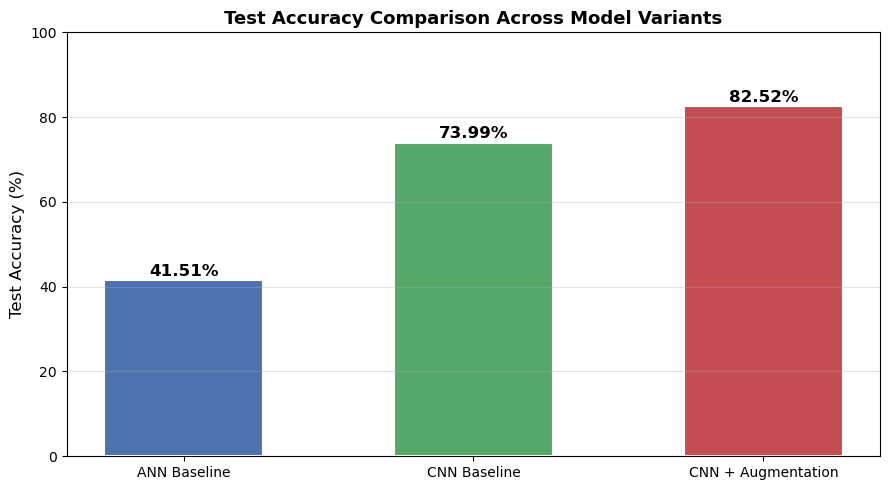

In [17]:
# Bar chart from the DataFrame
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = ax.bar(results_df.index,
              results_df['Test Accuracy (%)'],
              color=colors, edgecolor='white', linewidth=1.5, width=0.55)

for bar, val in zip(bars, results_df['Test Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 100)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Test Accuracy Comparison Across Model Variants', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.show()

##  Step 10 — Per-Class Analysis & Confusion Matrix

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_proba = aug_cnn_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test.flatten()

print('=== Per-Class Report — Augmented CNN ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Augmented CNN', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

##  Step 11 — Sample Predictions (Green = Correct, Red = Wrong)

In [ ]:
n = 20
indices = np.random.choice(len(X_test), n, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('Sample Predictions — Augmented CNN', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flat, indices):
    pred  = y_pred[idx]; true = y_true[idx]
    conf  = y_pred_proba[idx][pred] * 100
    color = 'green' if pred == true else 'red'
    ax.imshow(X_test[idx])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)
    ax.set_title(f'Pred: {CLASS_NAMES[pred]} ({conf:.0f}%)\nTrue: {CLASS_NAMES[true]}',
                 fontsize=9, color=color)
    ax.axis('off')

plt.tight_layout(); plt.show()

##  Key Concepts Reference

| Concept | What it does | Why it matters |
|---------|-------------|----------------|
| **Normalisation** | Scale pixels 0–255 → 0–1 | Stabilises gradient updates |
| **Conv2D** | Sliding-window feature detector | Captures spatial patterns |
| **BatchNormalization** | Normalise activations per batch | Speeds training, reduces sensitivity to init |
| **MaxPooling2D** | Downsample feature maps | Reduces params, adds translation invariance |
| **Dropout** | Randomly zero activations during training | Prevents overfitting |
| **RandomFlip / Rotate / Zoom** | Augment training images on-the-fly | Artificially expands dataset variety |
| **EarlyStopping** | Halt training when val metric stagnates | Saves time & avoids overfitting |
| **restore_best_weights=True** | Revert to the best epoch checkpoint | Ensures inference uses optimal weights |
| **Filter scaling 32→64→128** | Richer representations in deeper layers | Enables complex feature hierarchies |